<a href="https://colab.research.google.com/github/scudilio/FIAP_MBA-Feature_Engineering/blob/main/aula2_dados_desbalanceados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 Aula Prática: Tratamento de Dados Desbalanceados

## Disciplina: Feature Engineering

---

### 📋 Objetivo
Aprender a identificar e tratar problemas de **desbalanceamento de classes** usando técnicas de **Downsampling** e **Upsampling**.

### 📚 O que você vai aprender
1. Identificar dados desbalanceados
2. Entender por que isso é um problema
3. Aplicar **Undersampling** (reduzir classe majoritária)
4. Aplicar **Oversampling** (aumentar classe minoritária)
5. Usar **SMOTE** para criar dados sintéticos
6. Comparar resultados

### 🏢 Caso de Negócio: Detecção de Fraude
Uma empresa de cartão de crédito quer detectar transações fraudulentas. O problema: **apenas 2% das transações são fraudes!**

---
## 1️⃣ Setup: Importar Bibliotecas

In [ ]:
# Bibliotecas básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Imbalanced-learn (técnicas de balanceamento)
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.combine import SMOTETomek

# Configurações
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Bibliotecas carregadas!")

✅ Bibliotecas carregadas!


---
## 2️⃣ Carregar os Dados

In [ ]:
# Carregar dataset
df = pd.read_csv('https://raw.githubusercontent.com/scudilio/FIAP_MBA-Feature_Engineering/refs/heads/main/dados_fraude.csv')

print(f"📊 Shape: {df.shape}")
print(f"📊 Colunas: {list(df.columns)}")
df.head()

📊 Shape: (10000, 12)
📊 Colunas: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'Amount', 'Class']


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Amount,Class
0,-0.704812,1.043361,1.514990,-2.299988,-1.244497,-0.810090,0.723062,0.788892,0.519539,0.876395,243.300725,0
1,-0.239023,0.730196,0.418893,0.667152,0.603516,0.050120,-0.596204,-0.607755,-0.214646,0.843143,17.323038,0
2,-0.450668,2.259602,0.721162,0.256325,1.363546,0.301931,-0.505621,0.080160,1.038654,-1.992186,6.755864,0
3,-1.786495,-0.885170,-1.982901,-0.112563,-0.080788,-0.405504,0.538916,-0.723392,-1.297636,-0.797232,74.839395,0
4,0.479609,-0.108242,-1.575322,-0.503593,1.311574,0.292256,0.047291,-0.388794,-0.459958,0.543961,146.806150,0


In [ ]:
# Verificar informações básicas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      10000 non-null  float64
 1   V2      10000 non-null  float64
 2   V3      10000 non-null  float64
 3   V4      10000 non-null  float64
 4   V5      10000 non-null  float64
 5   V6      10000 non-null  float64
 6   V7      10000 non-null  float64
 7   V8      10000 non-null  float64
 8   V9      10000 non-null  float64
 9   V10     10000 non-null  float64
 10  Amount  10000 non-null  float64
 11  Class   10000 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 937.6 KB


In [ ]:
df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Amount,Class
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.042523,-0.031684,-0.008669,0.016310,0.012437,0.002649,0.012918,0.001693,0.001131,-0.005640,69.613828,0.020000
std,1.058489,1.013391,1.003031,1.006847,0.998175,1.001443,1.010710,1.001298,0.995909,0.991762,125.020229,0.140007
min,-4.295391,-4.465604,-3.940008,-3.631539,-3.856375,-3.726141,-4.462969,-3.601085,-3.419906,-4.157734,1.000000,0.000000
25%,-0.667453,-0.706000,-0.684620,-0.660570,-0.661041,-0.671775,-0.661183,-0.684996,-0.677070,-0.680137,15.345002,0.000000
50%,0.033711,-0.036563,-0.014492,0.024073,0.012248,0.009466,0.017331,0.001488,0.003151,0.003104,34.418753,0.000000
75%,0.735270,0.652297,0.664414,0.696967,0.690269,0.676462,0.698700,0.672743,0.672574,0.674684,77.506242,0.000000
max,5.080115,3.942331,3.829782,4.479084,3.594374,3.926238,3.602832,3.712795,3.605591,3.852731,5000.000000,1.000000


---
## 3️⃣ Entendendo o Desbalanceamento

### O que é?
Dados desbalanceados ocorrem quando uma classe tem **muito mais exemplos** que outra.

### Por que é um problema?
O modelo tende a **ignorar a classe minoritária** e prever sempre a classe majoritária.

In [ ]:
# Ver distribuição das classes
print("📊 Distribuição das Classes:")
print(df['Class'].value_counts())
print("\n📊 Percentual:")
print(df['Class'].value_counts(normalize=True) * 100)

📊 Distribuição das Classes:
Class
0    9800
1     200
Name: count, dtype: int64

📊 Percentual:
Class
0    98.0
1     2.0
Name: proportion, dtype: float64


In [ ]:
# Calcular ratio de desbalanceamento
n_legit = (df['Class'] == 0).sum()
n_fraud = (df['Class'] == 1).sum()
ratio = n_legit / n_fraud

print(f"⚖️ Ratio de desbalanceamento: {ratio:.0f}:1")
print(f"   Para cada fraude, existem {ratio:.0f} transações legítimas!")

⚖️ Ratio de desbalanceamento: 49:1
   Para cada fraude, existem 49 transações legítimas!


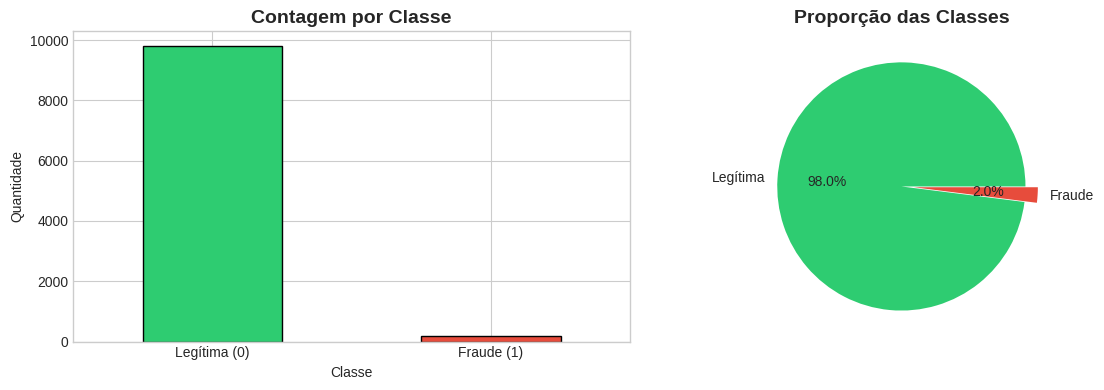

In [ ]:
# Visualizar o desbalanceamento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
colors = ['#2ecc71', '#e74c3c']
df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Contagem por Classe', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Quantidade')
axes[0].set_xticklabels(['Legítima (0)', 'Fraude (1)'], rotation=0)

# Gráfico de pizza
df['Class'].value_counts().plot(kind='pie', ax=axes[1], colors=colors,
                                 autopct='%1.1f%%', explode=[0, 0.1],
                                 labels=['Legítima', 'Fraude'])
axes[1].set_title('Proporção das Classes', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('fig1_desbalanceamento.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4️⃣ Preparar os Dados

In [ ]:
# Separar features (X) e target (y)
X = df.drop('Class', axis=1)
y = df['Class']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (10000, 11)
y shape: (10000,)


In [ ]:
# Dividir em treino e teste (ESTRATIFICADO!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y  # IMPORTANTE: mantém proporção das classes!
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"\nProporção de fraudes no treino: {y_train.mean()*100:.2f}%")
print(f"Proporção de fraudes no teste:  {y_test.mean()*100:.2f}%")

Treino: 7000 amostras
Teste:  3000 amostras

Proporção de fraudes no treino: 2.00%
Proporção de fraudes no teste:  2.00%


In [ ]:
# Escalonar as features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit só no treino!
X_test_scaled = scaler.transform(X_test)        # transform no teste

print("✅ Features escalonadas!")

✅ Features escalonadas!


---
## 5️⃣ Modelo BASELINE (Sem Tratamento)

Vamos ver como um modelo se comporta **sem nenhum tratamento** do desbalanceamento.

In [ ]:
# Treinar modelo baseline
modelo_baseline = LogisticRegression(random_state=42, max_iter=1000)
modelo_baseline.fit(X_train_scaled, y_train)

# Fazer predições
y_pred_baseline = modelo_baseline.predict(X_test_scaled)

# Avaliar
print("📊 BASELINE (Sem Tratamento)")
print("=" * 40)
print(classification_report(y_test, y_pred_baseline, target_names=['Legítima', 'Fraude']))

📊 BASELINE (Sem Tratamento)
              precision    recall  f1-score   support

    Legítima       0.99      1.00      0.99      2940
      Fraude       0.74      0.47      0.57        60

    accuracy                           0.99      3000
   macro avg       0.86      0.73      0.78      3000
weighted avg       0.98      0.99      0.98      3000



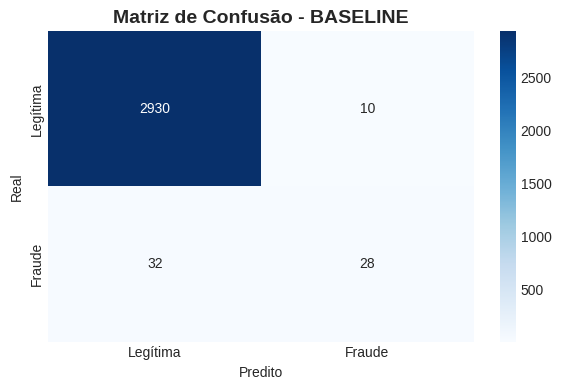

In [ ]:
# Matriz de confusão
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítima', 'Fraude'],
            yticklabels=['Legítima', 'Fraude'])
plt.title('Matriz de Confusão - BASELINE', fontsize=14, fontweight='bold')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('fig2_baseline_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6️⃣ UNDERSAMPLING (Downsampling)

### 💡 Conceito
**Reduzir** o número de amostras da classe **majoritária** para equilibrar com a minoritária.

### 📊 Ilustração

```
ANTES:                          DEPOIS:
                               
🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢            🟢🟢
🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢    →       🔴🔴
🔴🔴                           
                               
(100 verdes, 2 vermelhos)       (2 verdes, 2 vermelhos)
```

### ✅ Vantagens
- Rápido
- Reduz tempo de treinamento

### ❌ Desvantagens  
- **Perde informação** da classe majoritária

### 6.1 Random Undersampling
Remove aleatoriamente amostras da classe majoritária.

In [ ]:
# Aplicar Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)

print("📊 Random Undersampling")
print(f"   Antes:  {len(y_train)} amostras")
print(f"   Depois: {len(y_train_rus)} amostras")
print(f"\n   Distribuição depois:")
print(pd.Series(y_train_rus).value_counts())

📊 Random Undersampling
   Antes:  7000 amostras
   Depois: 280 amostras

   Distribuição depois:
Class
0    140
1    140
Name: count, dtype: int64


In [ ]:
# Treinar modelo com dados balanceados
modelo_rus = LogisticRegression(random_state=42, max_iter=1000)
modelo_rus.fit(X_train_rus, y_train_rus)

# Predições
y_pred_rus = modelo_rus.predict(X_test_scaled)

# Avaliar
print("📊 Random Undersampling")
print("=" * 40)
print(classification_report(y_test, y_pred_rus, target_names=['Legítima', 'Fraude']))

📊 Random Undersampling
              precision    recall  f1-score   support

    Legítima       1.00      0.92      0.96      2940
      Fraude       0.18      0.90      0.30        60

    accuracy                           0.92      3000
   macro avg       0.59      0.91      0.63      3000
weighted avg       0.98      0.92      0.94      3000



### 6.2 Tomek Links

**Tomek Links** são pares de amostras de classes diferentes que são vizinhos mais próximos.

O algoritmo **remove as amostras majoritárias** que formam esses pares, limpando a fronteira de decisão.

```
ANTES:                          DEPOIS:
                               
🟢🟢🟢🟢                         🟢🟢🟢🟢
      🟢🔴  ← Tomek Link   →           🔴
        🔴                            🔴
```

In [ ]:
# Aplicar Tomek Links
tomek = TomekLinks()
X_train_tomek, y_train_tomek = tomek.fit_resample(X_train_scaled, y_train)

print("📊 Tomek Links")
print(f"   Antes:  {len(y_train)} amostras")
print(f"   Depois: {len(y_train_tomek)} amostras")
print(f"   Removidos: {len(y_train) - len(y_train_tomek)} Tomek Links")

📊 Tomek Links
   Antes:  7000 amostras
   Depois: 6976 amostras
   Removidos: 24 Tomek Links


In [ ]:
# Treinar modelo
modelo_tomek = LogisticRegression(random_state=42, max_iter=1000)
modelo_tomek.fit(X_train_tomek, y_train_tomek)

# Predições
y_pred_tomek = modelo_tomek.predict(X_test_scaled)

# Avaliar
print("📊 Tomek Links")
print("=" * 40)
print(classification_report(y_test, y_pred_tomek, target_names=['Legítima', 'Fraude']))

📊 Tomek Links
              precision    recall  f1-score   support

    Legítima       0.99      1.00      0.99      2940
      Fraude       0.68      0.47      0.55        60

    accuracy                           0.98      3000
   macro avg       0.84      0.73      0.77      3000
weighted avg       0.98      0.98      0.98      3000



---
## 7️⃣ OVERSAMPLING (Upsampling)

### 💡 Conceito
**Aumentar** o número de amostras da classe **minoritária** para equilibrar com a majoritária.

### 📊 Ilustração

```
ANTES:                          DEPOIS:
                               
🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢            🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢
🔴🔴                    →       🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴
                               
(10 verdes, 2 vermelhos)        (10 verdes, 10 vermelhos)
```

### ✅ Vantagens
- Não perde informação

### ❌ Desvantagens  
- Aumenta tempo de treinamento
- Risco de **overfitting** (duplicação simples)

### 7.1 Random Oversampling
Duplica aleatoriamente amostras da classe minoritária.

In [ ]:
# Aplicar Random Oversampling
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_scaled, y_train)

print("📊 Random Oversampling")
print(f"   Antes:  {len(y_train)} amostras")
print(f"   Depois: {len(y_train_ros)} amostras")
print(f"\n   Distribuição depois:")
print(pd.Series(y_train_ros).value_counts())

📊 Random Oversampling
   Antes:  7000 amostras
   Depois: 13720 amostras

   Distribuição depois:
Class
0    6860
1    6860
Name: count, dtype: int64


In [ ]:
# Treinar modelo
modelo_ros = LogisticRegression(random_state=42, max_iter=1000)
modelo_ros.fit(X_train_ros, y_train_ros)

# Predições
y_pred_ros = modelo_ros.predict(X_test_scaled)

# Avaliar
print("📊 Random Oversampling")
print("=" * 40)
print(classification_report(y_test, y_pred_ros, target_names=['Legítima', 'Fraude']))

📊 Random Oversampling
              precision    recall  f1-score   support

    Legítima       1.00      0.92      0.96      2940
      Fraude       0.18      0.88      0.30        60

    accuracy                           0.92      3000
   macro avg       0.59      0.90      0.63      3000
weighted avg       0.98      0.92      0.94      3000



---
## 8️⃣ SMOTE (Synthetic Minority Over-sampling Technique)

### 💡 Conceito
SMOTE **cria novas amostras sintéticas** da classe minoritária através de **interpolação** entre amostras existentes.

### 📊 Como funciona?

```
1. Pegue uma amostra minoritária (A)
2. Encontre seus K vizinhos mais próximos (B, C, D...)
3. Escolha um vizinho aleatoriamente (ex: B)
4. Crie um ponto ENTRE A e B

     A ●━━━━━━━★━━━━━━● B
              ↑
         Novo ponto
         sintético
```

### 🔢 Fórmula
```
Novo_ponto = A + random(0,1) × (B - A)
```

### ✅ Vantagem sobre Random Oversampling
- Cria **diversidade** ao invés de apenas duplicar
- Menos propenso a overfitting

In [ ]:
# Aplicar SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("📊 SMOTE")
print(f"   Antes:  {len(y_train)} amostras")
print(f"   Depois: {len(y_train_smote)} amostras")
print(f"   Sintéticas criadas: {len(y_train_smote) - len(y_train)}")
print(f"\n   Distribuição depois:")
print(pd.Series(y_train_smote).value_counts())

📊 SMOTE
   Antes:  7000 amostras
   Depois: 13720 amostras
   Sintéticas criadas: 6720

   Distribuição depois:
Class
0    6860
1    6860
Name: count, dtype: int64


In [ ]:
# Treinar modelo
modelo_smote = LogisticRegression(random_state=42, max_iter=1000)
modelo_smote.fit(X_train_smote, y_train_smote)

# Predições
y_pred_smote = modelo_smote.predict(X_test_scaled)

# Avaliar
print("📊 SMOTE")
print("=" * 40)
print(classification_report(y_test, y_pred_smote, target_names=['Legítima', 'Fraude']))

📊 SMOTE
              precision    recall  f1-score   support

    Legítima       1.00      0.93      0.96      2940
      Fraude       0.21      0.85      0.33        60

    accuracy                           0.93      3000
   macro avg       0.60      0.89      0.65      3000
weighted avg       0.98      0.93      0.95      3000



### Visualizar efeito do SMOTE
Vamos ver como o SMOTE cria pontos sintéticos em um espaço 2D.

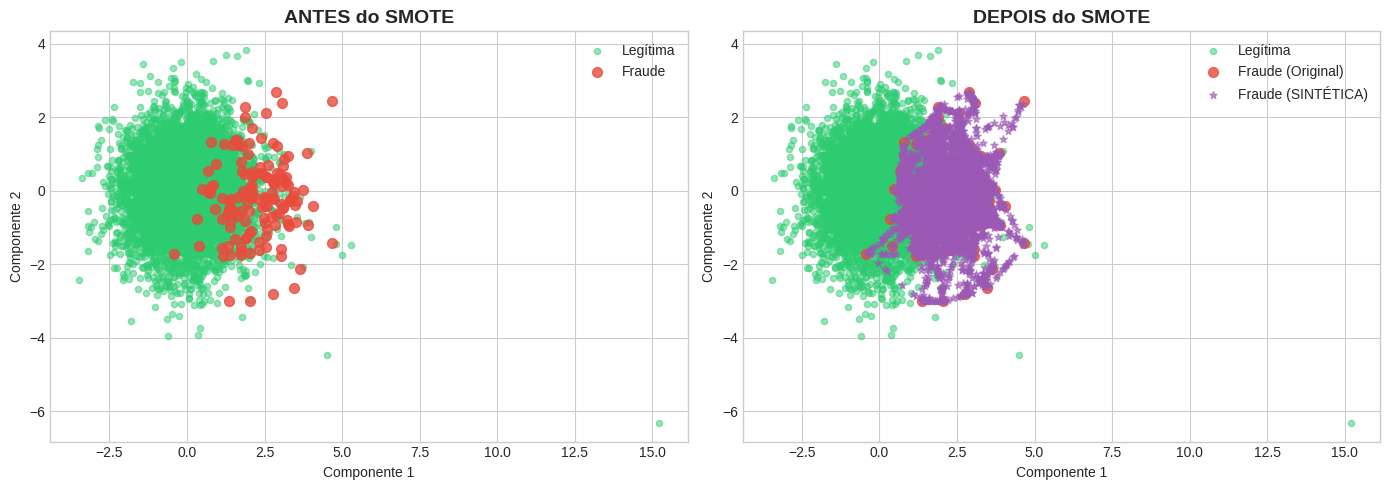

In [ ]:
# Visualizar em 2D usando PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_scaled)
X_train_smote_2d = pca.transform(X_train_smote)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ANTES do SMOTE
axes[0].scatter(X_train_2d[y_train == 0, 0], X_train_2d[y_train == 0, 1],
                c='#2ecc71', alpha=0.5, s=20, label='Legítima')
axes[0].scatter(X_train_2d[y_train == 1, 0], X_train_2d[y_train == 1, 1],
                c='#e74c3c', alpha=0.8, s=50, label='Fraude')
axes[0].set_title('ANTES do SMOTE', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Componente 1')
axes[0].set_ylabel('Componente 2')
axes[0].legend()

# DEPOIS do SMOTE
n_original = len(y_train)
axes[1].scatter(X_train_smote_2d[y_train_smote == 0, 0], X_train_smote_2d[y_train_smote == 0, 1],
                c='#2ecc71', alpha=0.5, s=20, label='Legítima')

# Fraudes originais
mask_original = np.zeros(len(y_train_smote), dtype=bool)
mask_original[:n_original] = True
mask_fraud_orig = (y_train_smote == 1) & mask_original
axes[1].scatter(X_train_smote_2d[mask_fraud_orig, 0], X_train_smote_2d[mask_fraud_orig, 1],
                c='#e74c3c', alpha=0.8, s=50, label='Fraude (Original)')

# Fraudes sintéticas
mask_fraud_sint = (y_train_smote == 1) & ~mask_original
axes[1].scatter(X_train_smote_2d[mask_fraud_sint, 0], X_train_smote_2d[mask_fraud_sint, 1],
                c='#9b59b6', alpha=0.6, s=30, marker='*', label='Fraude (SINTÉTICA)')

axes[1].set_title('DEPOIS do SMOTE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Componente 1')
axes[1].set_ylabel('Componente 2')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig3_efeito_smote.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9️⃣ SMOTE + Tomek Links (Combinação)

### 💡 Conceito
Combina **oversampling (SMOTE)** com **undersampling (Tomek Links)**:

1. Primeiro aplica **SMOTE** para criar amostras sintéticas
2. Depois aplica **Tomek Links** para limpar a fronteira de decisão

### 📊 Ilustração

```
Original → SMOTE → Tomek Links → Final
   
🟢🟢🟢🟢    🟢🟢🟢🟢    🟢🟢🟢🟢      🟢🟢🟢🟢
🔴        →  🔴🔴🔴🔴  →  🔴🔴🔴       →  🔴🔴🔴
             (criar)    (limpar)       (balanceado
                                        e limpo)
```

In [ ]:
# Aplicar SMOTE + Tomek Links
smote_tomek = SMOTETomek(random_state=42)
X_train_st, y_train_st = smote_tomek.fit_resample(X_train_scaled, y_train)

print("📊 SMOTE + Tomek Links")
print(f"   Antes:  {len(y_train)} amostras")
print(f"   Depois: {len(y_train_st)} amostras")
print(f"\n   Distribuição depois:")
print(pd.Series(y_train_st).value_counts())

📊 SMOTE + Tomek Links
   Antes:  7000 amostras
   Depois: 13720 amostras

   Distribuição depois:
Class
0    6860
1    6860
Name: count, dtype: int64


In [ ]:
# Treinar modelo
modelo_st = LogisticRegression(random_state=42, max_iter=1000)
modelo_st.fit(X_train_st, y_train_st)

# Predições
y_pred_st = modelo_st.predict(X_test_scaled)

# Avaliar
print("📊 SMOTE + Tomek Links")
print("=" * 40)
print(classification_report(y_test, y_pred_st, target_names=['Legítima', 'Fraude']))

📊 SMOTE + Tomek Links
              precision    recall  f1-score   support

    Legítima       1.00      0.93      0.96      2940
      Fraude       0.21      0.85      0.33        60

    accuracy                           0.93      3000
   macro avg       0.60      0.89      0.65      3000
weighted avg       0.98      0.93      0.95      3000



---
## 🔟 Comparação dos Resultados

Vamos comparar todas as técnicas aplicadas.

In [ ]:
# Coletar métricas de todos os modelos
from sklearn.metrics import precision_score, recall_score, f1_score

resultados = {
    'Baseline': y_pred_baseline,
    'Random Under': y_pred_rus,
    'Tomek Links': y_pred_tomek,
    'Random Over': y_pred_ros,
    'SMOTE': y_pred_smote,
    'SMOTE+Tomek': y_pred_st
}

# Calcular métricas
metricas = []
for nome, y_pred in resultados.items():
    metricas.append({
        'Técnica': nome,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

df_metricas = pd.DataFrame(metricas)
df_metricas = df_metricas.round(4)
df_metricas = df_metricas.sort_values('F1-Score', ascending=False)

print("📊 Comparação de Métricas (ordenado por F1-Score)")
print("=" * 55)
print(df_metricas.to_string(index=False))

📊 Comparação de Métricas (ordenado por F1-Score)
     Técnica  Precision  Recall  F1-Score
    Baseline     0.7368  0.4667    0.5714
 Tomek Links     0.6829  0.4667    0.5545
 SMOTE+Tomek     0.2082  0.8500    0.3344
       SMOTE     0.2082  0.8500    0.3344
Random Under     0.1824  0.9000    0.3034
 Random Over     0.1803  0.8833    0.2994


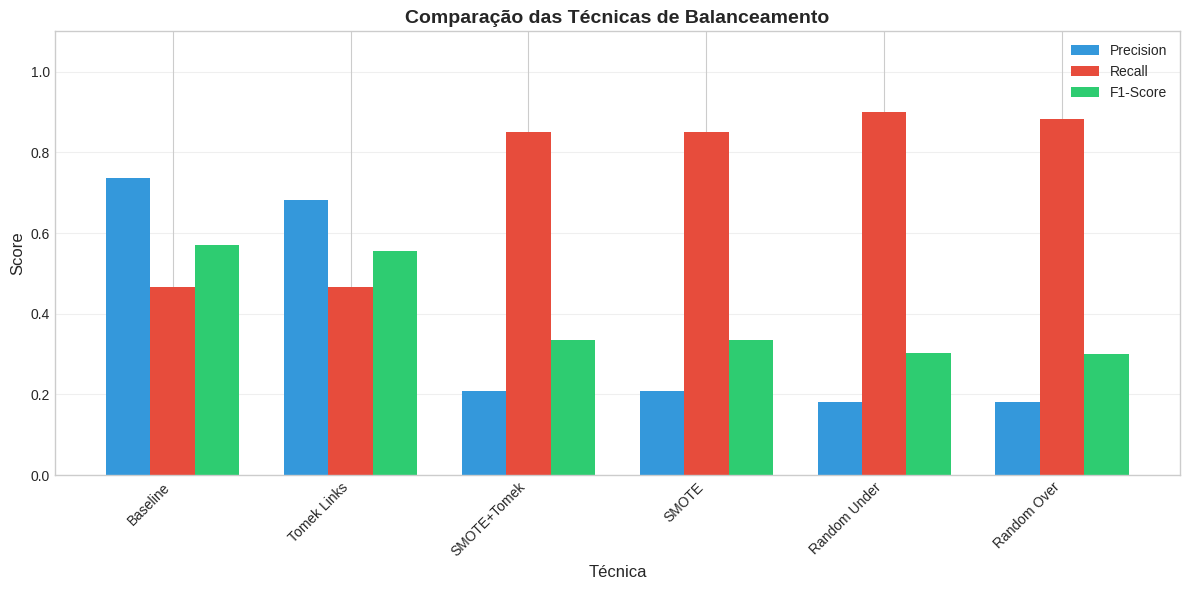

In [ ]:
# Gráfico comparativo
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_metricas))
width = 0.25

bars1 = ax.bar(x - width, df_metricas['Precision'], width, label='Precision', color='#3498db')
bars2 = ax.bar(x, df_metricas['Recall'], width, label='Recall', color='#e74c3c')
bars3 = ax.bar(x + width, df_metricas['F1-Score'], width, label='F1-Score', color='#2ecc71')

ax.set_xlabel('Técnica', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparação das Técnicas de Balanceamento', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_metricas['Técnica'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()

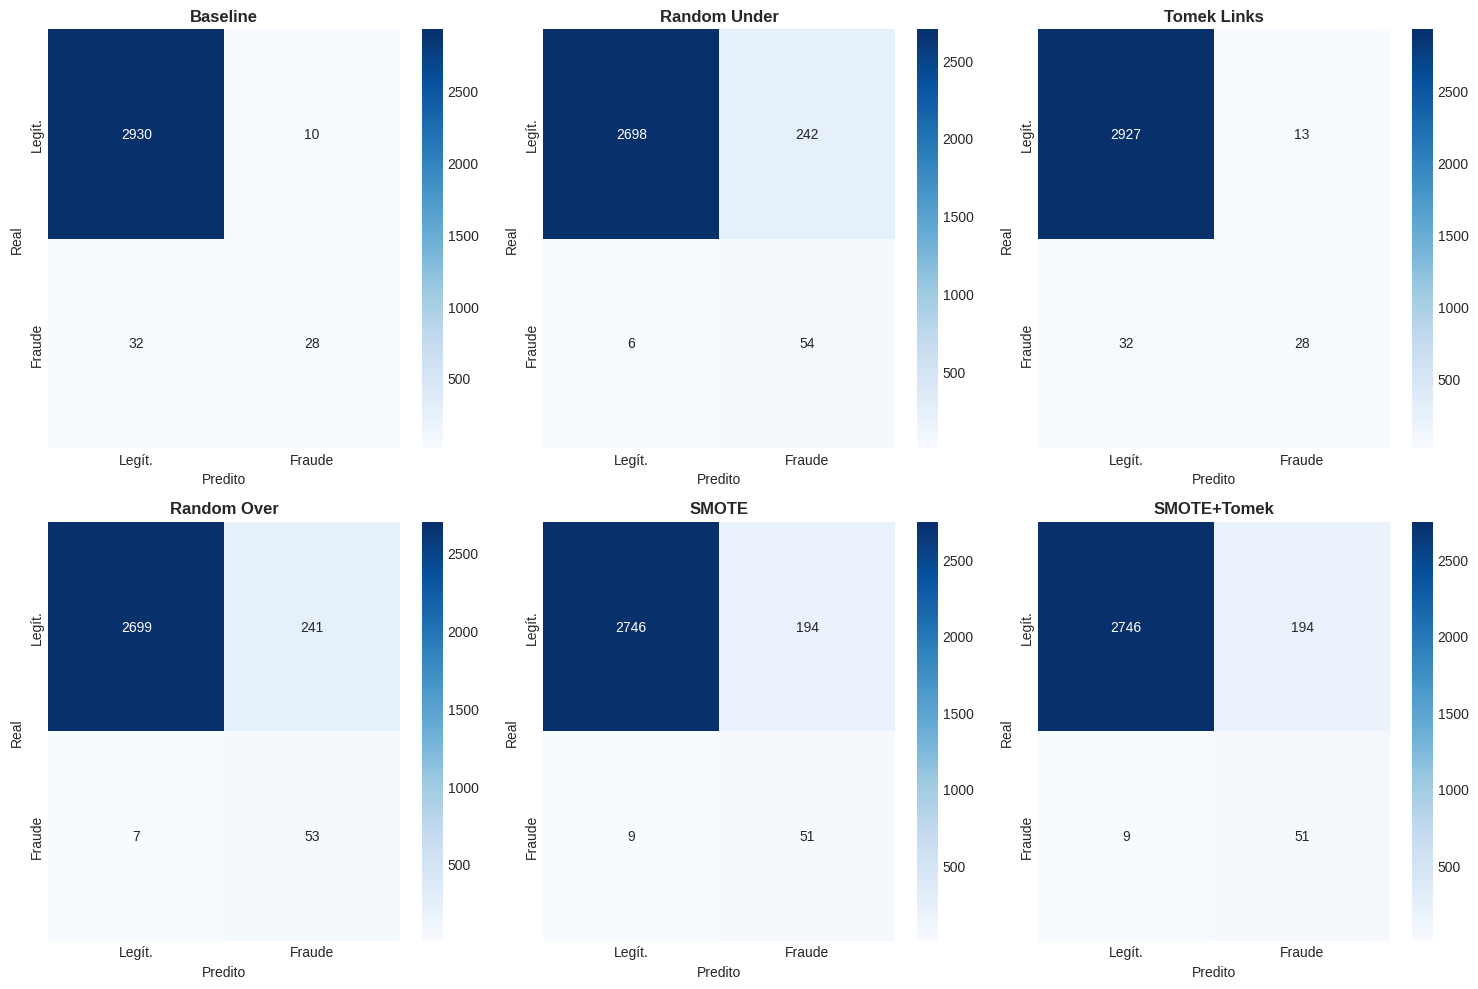

In [ ]:
# Matrizes de confusão lado a lado
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (nome, y_pred) in enumerate(resultados.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Legít.', 'Fraude'],
                yticklabels=['Legít.', 'Fraude'])
    axes[idx].set_title(nome, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predito')
    axes[idx].set_ylabel('Real')

plt.tight_layout()
plt.savefig('fig5_matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📝 Resumo: Quando Usar Cada Técnica?

| Técnica | Quando Usar | Cuidados |
|---------|-------------|----------|
| **Random Undersampling** | Muitos dados, tempo limitado | Perde informação |
| **Tomek Links** | Limpar fronteira de decisão | Não balanceia completamente |
| **Random Oversampling** | Poucos dados, rápido | Risco de overfitting |
| **SMOTE** | Caso geral, bom equilíbrio | Pode criar ruído |
| **SMOTE + Tomek** | Melhor qualidade | Mais lento |

---

## ⚠️ Boas Práticas

1. **Sempre faça o split ANTES** do balanceamento
2. **Balanceie apenas o treino**, nunca o teste
3. **Use `stratify=y`** no train_test_split
4. **Não use apenas Accuracy** - olhe Precision, Recall e F1
5. **Considere o negócio**: o que custa mais, FP ou FN?

---
## 🎓 Exercício Proposto

1. Teste outras técnicas: `BorderlineSMOTE`, `ADASYN`
2. Experimente diferentes valores de `sampling_strategy` (ex: 0.5, 0.7)
3. Compare com a opção `class_weight='balanced'` da LogisticRegression
4. Use `RandomForestClassifier` e compare os resultados

In [ ]:
# Espaço para exercícios
# ...

---
## ✅ FIM DA AULA

**Você aprendeu:**
- O que são dados desbalanceados e por que são um problema
- Técnicas de **Undersampling**: Random, Tomek Links
- Técnicas de **Oversampling**: Random, SMOTE
- Técnicas **combinadas**: SMOTE + Tomek
- Como comparar e avaliar os resultados